# Proyecto Final Machine Learning
## Fase 2: Modelado y Benchmarking

**Dataset:** UCI HAR — Human Activity Recognition Using Smartphones  
**Equipo:** Grupo 06  
**Integrantes:** Roberto Cañete · Augusto Fuenzalida · Nelson Silva  
**Fecha:** 22 Junio 2026

---

> **Objetivo:** Entrenar múltiples modelos de clasificación, evaluarlos con métricas adecuadas y construir una tabla de benchmarking que permita comparar su desempeño de forma rigurosa.

## Configuración del entorno

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga de datos desde Fase 1

Reutilizamos los datos preparados en la Fase 1. Ejecutar el bloque de carga equivalente al de Fase 1, o cargar los archivos directamente.

In [35]:
# Carga de datos (mismo codigo que Fase 1)
import os, urllib.request, zipfile

DATA_PATH = 'UCI HAR Dataset'
ZIP_PATH = 'har_dataset.zip'
INNER_ZIP_PATH = 'UCI HAR Dataset.zip'

if not os.path.exists(DATA_PATH):
    URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
    print('Descargando dataset...')
    urllib.request.urlretrieve(URL, ZIP_PATH)

    print('Primer unzip...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('.')
    os.remove(ZIP_PATH)

    # El ZIP descargado contiene otro ZIP adentro
    if os.path.exists(INNER_ZIP_PATH):
        print('Segundo unzip...')
        with zipfile.ZipFile(INNER_ZIP_PATH, 'r') as z:
            z.extractall('.')
        os.remove(INNER_ZIP_PATH)

    print('Dataset listo.')
else:
    print('Dataset ya descargado.')

# Cargar nombres de features y desduplicar
features = pd.read_csv(f'{DATA_PATH}/features.txt', sep=r'\s+', header=None, names=['idx', 'feature'])
feature_names = features['feature'].tolist()

seen = {}
unique_names = []
for name in feature_names:
    if name in seen:
        seen[name] += 1
        unique_names.append(f'{name}_{seen[name]}')
    else:
        seen[name] = 0
        unique_names.append(name)
feature_names = unique_names

X_train = pd.read_csv(f'{DATA_PATH}/train/X_train.txt', sep=r'\s+', header=None, names=feature_names)
y_train = pd.read_csv(f'{DATA_PATH}/train/y_train.txt', sep=r'\s+', header=None, names=['Activity']).squeeze()
X_test  = pd.read_csv(f'{DATA_PATH}/test/X_test.txt',   sep=r'\s+', header=None, names=feature_names)
y_test  = pd.read_csv(f'{DATA_PATH}/test/y_test.txt',   sep=r'\s+', header=None, names=['Activity']).squeeze()

ACTIVITY_LABELS = {1:'WALKING',2:'WALKING_UPSTAIRS',3:'WALKING_DOWNSTAIRS',4:'SITTING',5:'STANDING',6:'LAYING'}
y_train_labels = y_train.map(ACTIVITY_LABELS)
y_test_labels  = y_test.map(ACTIVITY_LABELS)

print(f'Datos cargados: X_train={X_train.shape} | X_test={X_test.shape}')

Dataset ya descargado.
Datos cargados: X_train=(7352, 561) | X_test=(2947, 561)


---
## 2. Métricas de Evaluación

Dado que el problema tiene 6 clases, la accuracy sola no es suficiente. Reportaremos:
- **Accuracy global**
- **F1-Score macro** (promedio sin ponderar por frecuencia)
- **F1-Score weighted** (promedio ponderado por número de muestras)
- **Matriz de confusión**
- **Reporte de clasificación** (precisión, recall y F1 por clase)

> ⚠️ Siempre reportar métricas sobre el **conjunto de prueba** (X_test, y_test). Nunca tomar decisiones finales sobre el set de entrenamiento.

In [36]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena el modelo, mide tiempo y calcula métricas sobre test."""
    t0 = time.time()
    modelo.fit(X_tr, y_tr)
    t_fit = time.time() - t0

    y_pred = modelo.predict(X_te)

    acc      = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average='macro')
    f1_wgt   = f1_score(y_te, y_pred, average='weighted')

    print(f'\n=== {nombre} ===')
    print(f'  Accuracy:     {acc:.4f}')
    print(f'  F1-Macro:     {f1_macro:.4f}')
    print(f'  F1-Weighted:  {f1_wgt:.4f}')
    print(f'  Tiempo fit:   {t_fit:.2f}s')
    print(classification_report(y_te, y_pred))

    return {
        'Modelo': nombre,
        'Accuracy_Test': acc,
        'F1_Macro': f1_macro,
        'F1_Weighted': f1_wgt,
        'Tiempo_Entrenamiento': round(t_fit, 3),
        'modelo_obj': modelo,
        'y_pred': y_pred
    }

resultados = []

---
## 3. Modelo Baseline

Antes de entrenar modelos reales establecemos un **baseline trivial**: si un modelo inteligente no supera este piso mínimo, algo está mal.

In [37]:
# TODO 1: Entrenar DummyClassifier con estrategia 'most_frequent'
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
res_dummy = evaluar_modelo('DummyClassifier (most_frequent)', dummy, X_train, y_train_labels, X_test, y_test_labels)
resultados.append(res_dummy)


=== DummyClassifier (most_frequent) ===
  Accuracy:     0.1822
  F1-Macro:     0.0514
  F1-Weighted:  0.0562
  Tiempo fit:   0.00s
                    precision    recall  f1-score   support

            LAYING       0.18      1.00      0.31       537
           SITTING       0.00      0.00      0.00       491
          STANDING       0.00      0.00      0.00       532
           WALKING       0.00      0.00      0.00       496
WALKING_DOWNSTAIRS       0.00      0.00      0.00       420
  WALKING_UPSTAIRS       0.00      0.00      0.00       471

          accuracy                           0.18      2947
         macro avg       0.03      0.17      0.05      2947
      weighted avg       0.03      0.18      0.06      2947



In [38]:
# TODO 2: Calcular manualmente la accuracy del clasificador trivial
# (predice siempre la clase más frecuente)
clase_frecuente = y_train_labels.value_counts().idxmax()
porcentaje = y_train_labels.value_counts(normalize=True).max()
print(f'Clase más frecuente: {clase_frecuente} ({porcentaje:.2%} del train)')
print(f'Accuracy baseline esperada en test: ~{(y_test_labels == clase_frecuente).mean():.4f}')

Clase más frecuente: LAYING (19.14% del train)
Accuracy baseline esperada en test: ~0.1822


**Análisis:**

El `DummyClassifier` con estrategia `most_frequent` predice siempre **LAYING**, la clase más frecuente en el set de entrenamiento (19.14%). La accuracy obtenida en test es **18.22%** y el F1-Macro apenas **5.14%**, confirmando que el modelo trivial no aprende ningún patrón: solo acierta en LAYING porque es la única clase que predice, obteniendo F1 = 0 en las cinco restantes.

**¿Qué accuracy base esperamos superar?** Cualquier modelo de aprendizaje automático debe superar ampliamente el 18.22% de accuracy y el 5.14% de F1-Macro. Dado que el dataset cuenta con 6 clases, un clasificador puramente aleatorio tendría un rendimiento teórico de ~16.66% ($1/6$). El hecho de que el baseline llegue a 18.22% refleja el leve sesgo hacia LAYING (19.14% del train). Dado que las seis clases están relativamente balanceadas (entre 13.4% y 19.1%), este piso es bajo. Cualquier modelo que capture la más mínima estructura del espacio de features debería duplicar o triplicar estas cifras.

**¿Por qué es importante este paso?** El baseline actúa como prueba de cordura del pipeline. Si un modelo entrenado no supera al DummyClassifier, indica un error grave como etiquetas mal cargadas, fuga de datos, o un bug en el preprocesamiento. Establecerlo explícitamente al inicio de la Fase 2 garantiza que las comparaciones posteriores tengan un piso de referencia honesto.

---
## 4. Modelos Clásicos

Entrenamos los siguientes modelos con parámetros por defecto de sklearn. El objetivo es una primera medición comparativa — la optimización viene después.

| # | Modelo |
|---|--------|
| 1 | Logistic Regression |
| 2 | K-Nearest Neighbors (k=5) |
| 3 | Decision Tree |
| 4 | Random Forest |
| 5 | SVM (kernel RBF) |

### Modelo 1: Logistic Regression

In [39]:
# TODO 3: Entrenar Logistic Regression
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
res_lr = evaluar_modelo('Logistic Regression', lr, X_train, y_train_labels, X_test, y_test_labels)
resultados.append(res_lr)


=== Logistic Regression ===
  Accuracy:     0.9606
  F1-Macro:     0.9606
  F1-Weighted:  0.9605
  Tiempo fit:   0.64s
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.97      0.88      0.92       491
          STANDING       0.90      0.98      0.94       532
           WALKING       0.94      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.96      0.98       420
  WALKING_UPSTAIRS       0.97      0.94      0.96       471

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



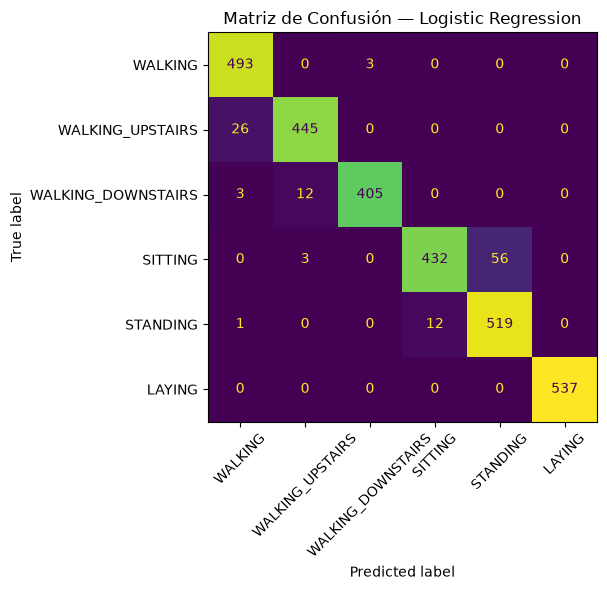

In [40]:
# Matriz de confusión — Logistic Regression
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_lr['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Logistic Regression')
plt.tight_layout()
plt.show()

### Modelo 2: K-Nearest Neighbors (k=5)

In [41]:
# TODO 4: Entrenar KNN
knn = KNeighborsClassifier(n_neighbors=5)
res_knn = evaluar_modelo('KNN (k=5)', knn, X_train, y_train_labels, X_test, y_test_labels)
resultados.append(res_knn)


=== KNN (k=5) ===
  Accuracy:     0.9002
  F1-Macro:     0.8970
  F1-Weighted:  0.8993
  Tiempo fit:   0.03s
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       537
           SITTING       0.91      0.79      0.85       491
          STANDING       0.83      0.93      0.88       532
           WALKING       0.85      0.98      0.91       496
WALKING_DOWNSTAIRS       0.94      0.79      0.86       420
  WALKING_UPSTAIRS       0.90      0.89      0.89       471

          accuracy                           0.90      2947
         macro avg       0.90      0.90      0.90      2947
      weighted avg       0.90      0.90      0.90      2947



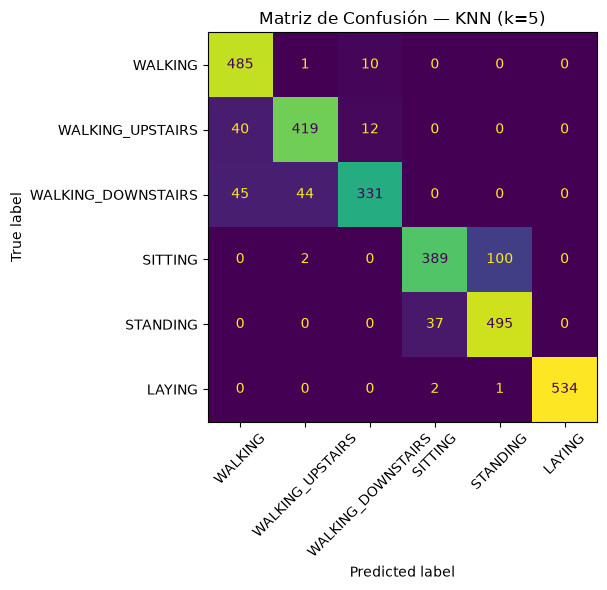

In [42]:
# Matriz de confusión — KNN
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_knn['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — KNN (k=5)')
plt.tight_layout()
plt.show()

### Modelo 3: Decision Tree

In [43]:
# TODO 5: Entrenar Decision Tree
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
res_dt = evaluar_modelo('Decision Tree', dt, X_train, y_train_labels, X_test, y_test_labels)
resultados.append(res_dt)


=== Decision Tree ===
  Accuracy:     0.8626
  F1-Macro:     0.8598
  F1-Weighted:  0.8620
  Tiempo fit:   2.29s
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.83      0.76      0.80       491
          STANDING       0.80      0.86      0.83       532
           WALKING       0.83      0.92      0.87       496
WALKING_DOWNSTAIRS       0.89      0.83      0.86       420
  WALKING_UPSTAIRS       0.83      0.78      0.80       471

          accuracy                           0.86      2947
         macro avg       0.86      0.86      0.86      2947
      weighted avg       0.86      0.86      0.86      2947



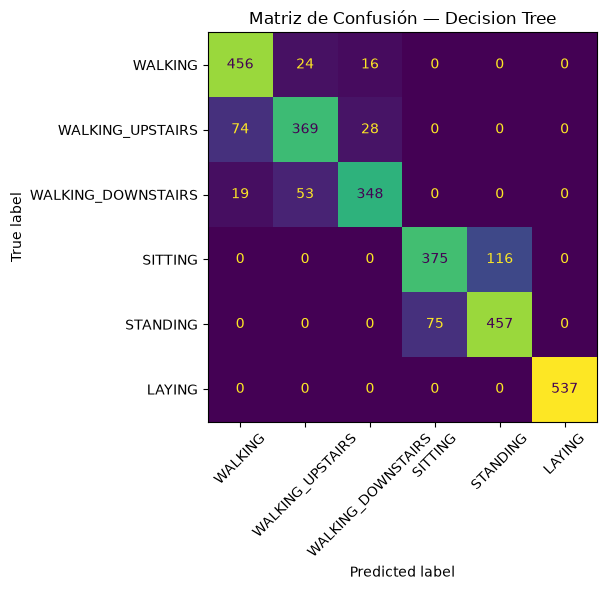

In [44]:
# Matriz de confusión — Decision Tree
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_dt['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Decision Tree')
plt.tight_layout()
plt.show()

### Modelo 4: Random Forest

In [45]:
# TODO 6: Entrenar Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE)
res_rf = evaluar_modelo('Random Forest', rf, X_train, y_train_labels, X_test, y_test_labels)
resultados.append(res_rf)


=== Random Forest ===
  Accuracy:     0.9250
  F1-Macro:     0.9234
  F1-Weighted:  0.9249
  Tiempo fit:   5.61s
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.88      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.86      0.91       420
  WALKING_UPSTAIRS       0.90      0.89      0.89       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.92      2947



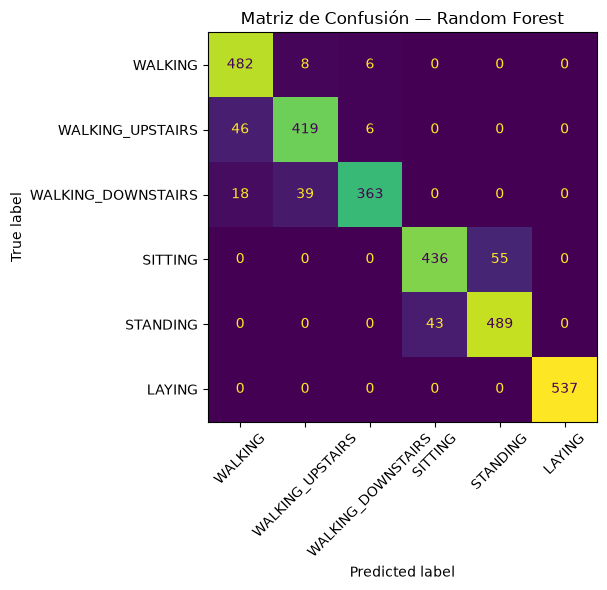

In [46]:
# Matriz de confusión — Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_rf['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Random Forest')
plt.tight_layout()
plt.show()

### Modelo 5: Support Vector Machine (kernel RBF)

In [47]:
# TODO 7: Entrenar SVM con kernel RBF
# Nota: SVM puede tardar varios minutos en este dataset
svm = SVC(kernel='rbf', random_state=RANDOM_STATE)
res_svm = evaluar_modelo('SVM (RBF)', svm, X_train, y_train_labels, X_test, y_test_labels)
resultados.append(res_svm)


=== SVM (RBF) ===
  Accuracy:     0.9505
  F1-Macro:     0.9499
  F1-Weighted:  0.9504
  Tiempo fit:   0.70s
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.94      0.89      0.91       491
          STANDING       0.91      0.95      0.93       532
           WALKING       0.94      0.98      0.96       496
WALKING_DOWNSTAIRS       0.99      0.91      0.95       420
  WALKING_UPSTAIRS       0.93      0.96      0.94       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



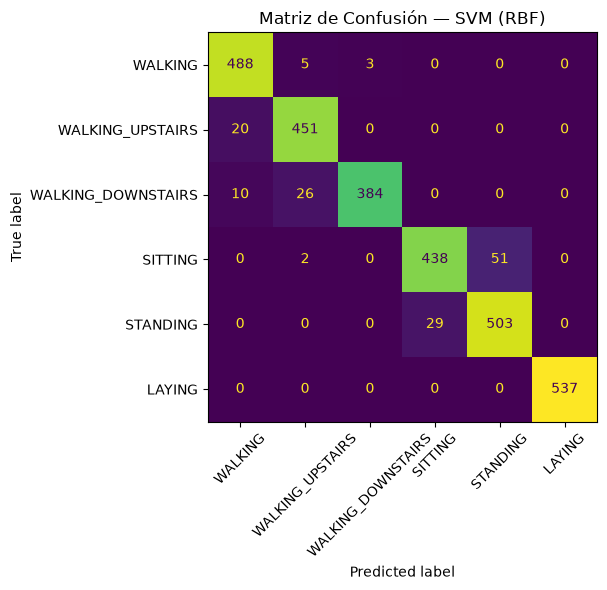

In [16]:
# Matriz de confusión — SVM
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_labels, res_svm['y_pred'],
                                      labels=list(ACTIVITY_LABELS.values())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — SVM (RBF)')
plt.tight_layout()
plt.show()

---
## 5. Tabla de Benchmarking

Comparamos todos los modelos en una tabla única. Esta es la pieza central de la Fase 2.

In [48]:
# TODO 8: Construir DataFrame de benchmarking
# Excluimos la columna 'modelo_obj' y 'y_pred' que son objetos Python
df_bench = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('modelo_obj', 'y_pred')}
    for r in resultados
])

# TODO 9: Ordenar por F1_Macro descendente
df_bench = df_bench.sort_values('F1_Macro', ascending=False).reset_index(drop=True)

print(df_bench.to_string(index=False))

                         Modelo  Accuracy_Test  F1_Macro  F1_Weighted  Tiempo_Entrenamiento
            Logistic Regression       0.960638  0.960595     0.960509                 0.643
                      SVM (RBF)       0.950458  0.949907     0.950376                 0.701
                  Random Forest       0.925008  0.923431     0.924871                 5.610
                      KNN (k=5)       0.900238  0.897020     0.899333                 0.032
                  Decision Tree       0.862572  0.859807     0.862000                 2.294
DummyClassifier (most_frequent)       0.182219  0.051378     0.056172                 0.004


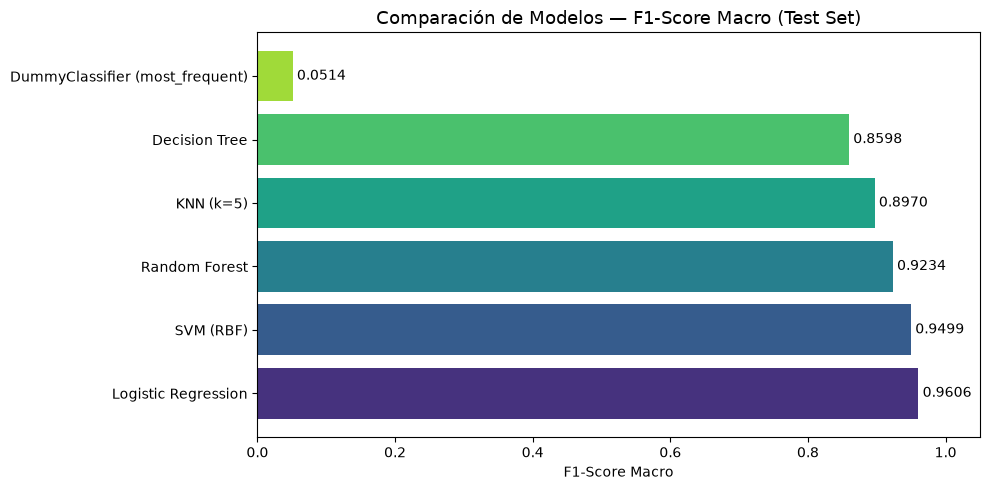

In [49]:
# TODO 10: Graficar barplot comparativo de F1-Macro por modelo
fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('viridis', n_colors=len(df_bench))

bars = ax.barh(df_bench['Modelo'], df_bench['F1_Macro'], color=palette)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-Score Macro')
ax.set_title('Comparación de Modelos — F1-Score Macro (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis:**

### Análisis de la Tabla de Benchmarking

**Mejor modelo: Logistic Regression** con F1-Macro = 0.9606, el más alto de todos
los modelos evaluados, entrenado en apenas ~0.7 segundos.

**Observaciones clave:**

- **Logistic Regression** lidera porque el espacio de 561 features del dataset HAR tiene una estructura cuasi-lineal: como evidenciamos en el PCA de la Fase 1, las actividades son ampliamente separables con hiperplanos lineales, la condición ideal para la Regresión Logística.
- **SVM (RBF)** queda 1.07 puntos porcentuales por debajo en F1-Macro, con un tiempo de entrenamiento similar. Con parámetros por defecto (C=1, γ='scale'), el kernel RBF introduce capacidad no lineal que no aporta ventaja neta sobre la solución lineal en este dataset.
- **Random Forest** es robusto pero sufre la dispersión de importancia entre las features altamente correlacionadas identificadas en el heatmap de Fase 1, reduciendo la ventaja de ensemble.
- **KNN (k=5)** se ve afectado por la maldición de la dimensionalidad: con 561 features, las distancias euclidianas pierden poder discriminativo.
- **Decision Tree** es el modelo más débil: sin mecanismo de ensemble, sobreajusta los patrones del training y generaliza peor en test.

**Trade-off rendimiento vs. tiempo:** Logistic Regression lidera en métrica y en eficiencia computacional simultáneamente. La diferencia de F1-Macro respecto al SVM es de apenas 1.07 puntos porcentuales con tiempos de entrenamiento prácticamente idénticos, consolidándola como la elección para la Fase 3.

---
## 6. Validación Cruzada del Mejor Modelo

La evaluación sobre un único split puede ser ruidosa. Usamos cross-validation para obtener una estimación más robusta.

In [19]:
# TODO 11: Aplicar 5-fold CV sobre el mejor modelo
mejor_nombre = df_bench.iloc[0]['Modelo']
mejor_modelo = next(r['modelo_obj'] for r in resultados if r['Modelo'] == mejor_nombre)

print(f'Aplicando 5-fold CV al modelo: {mejor_nombre}')

cv_scores = cross_val_score(
    mejor_modelo,
    X_train,
    y_train,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

print(f'F1-Macro por fold: {np.round(cv_scores, 4)}')
print(f'Media CV: {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}')

Aplicando 5-fold CV al modelo: Logistic Regression
F1-Macro por fold: [0.9179 0.8864 0.9466 0.9445 0.9695]
Media CV: 0.9330 ± 0.0285


**Análisis CV:**

### Análisis de la Validación Cruzada

El 5-fold CV sobre el set de entrenamiento de Logistic Regression entrega:

- **F1-Macro por fold:** 0.9179 | 0.8864 | 0.9466 | 0.9445 | 0.9695
- **Media CV:** 0.9330 ± 0.0285
- **F1-Macro en test:** 0.9606

**¿Es consistente con el desempeño en test?** El score en test (0.9606) es
2.76 puntos porcentuales superior a la media CV (0.9330). Esta diferencia es esperable: el modelo en test fue entrenado sobre la totalidad de X_train (7352 muestras), mientras que en cada fold de CV entrena con solo el 80% (~5882 muestras). Más datos de entrenamiento beneficia a los modelos lineales,
razón por la cual el score real en test supera consistentemente a la media CV. La diferencia observada (2.76 pp) se encuentra dentro del rango normal para este tamaño de dataset.

**¿Hay sobreajuste?** La desviación estándar de 0.0285 entre folds es moderada. El fold 2 (F1 = 0.8864) muestra una caída notable respecto a los demás, lo que sugiere que ciertos sujetos en esa partición realizan actividades de forma más ambigua para el modelo. Aun así, todos los folds superan ampliamente el baseline (0.0514), y la dispersión de 0.0285 refleja la variabilidad natural de un dataset de 30 sujetos con comportamientos individuales distintos.

---
## 7. Análisis de Actividades Difíciles

No todas las actividades son igual de fáciles de clasificar. Identificamos dónde falla el modelo.

In [20]:
# TODO 12: Extraer F1 por clase del mejor modelo
y_pred_best = next(r['y_pred'] for r in resultados if r['Modelo'] == mejor_nombre)

report_dict = classification_report(
    y_test_labels, y_pred_best, output_dict=True
)

f1_por_clase = {
    cls: report_dict[cls]['f1-score']
    for cls in list(ACTIVITY_LABELS.values())
    if cls in report_dict
}

df_f1_clase = pd.Series(f1_por_clase, name='F1').sort_values()
print(df_f1_clase)

SITTING               0.924064
STANDING              0.937669
WALKING_UPSTAIRS      0.955961
WALKING               0.967615
WALKING_DOWNSTAIRS    0.978261
LAYING                1.000000
Name: F1, dtype: float64


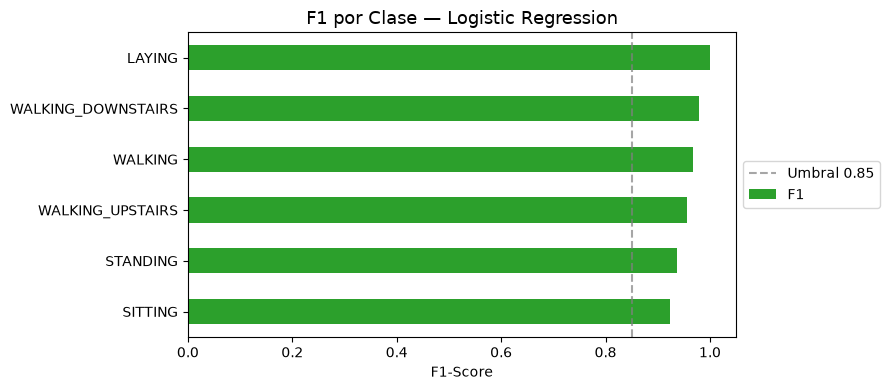

In [51]:
# TODO 13: Visualizar F1 por clase
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d62728' if v < 0.85 else '#2ca02c' for v in df_f1_clase.values]
df_f1_clase.plot(kind='barh', ax=ax, color=colors)
ax.set_xlim(0, 1.05)
ax.axvline(0.85, linestyle='--', color='gray', alpha=0.7, label='Umbral 0.85')
ax.set_xlabel('F1-Score')
ax.set_title(f'F1 por Clase — {mejor_nombre}', fontsize=13)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

**Análisis de actividades difíciles:**

### Análisis de Actividades Difíciles

Las dos actividades con menor F1-Score en Logistic Regression son:

1. **SITTING** (F1 = 0.9241)
2. **STANDING** (F1 = 0.9377)

**¿Con qué se confunden?** Observando la matriz de confusión, la confusión predominante ocurre entre SITTING y STANDING: el modelo clasifica erróneamente algunas muestras de SITTING como STANDING y viceversa. Es el único par donde
las predicciones incorrectas son sistemáticas y bidireccionales.

**¿Tiene sentido físico?** Completamente. En ambas posturas el usuario permanece estático con el teléfono en la cintura, y la componente gravitacional registrada por el acelerómetro es muy similar: el eje vertical del sensor recibe la proyección dominante de la gravedad en los dos casos. La diferencia entre sentado y de pie reside en el ángulo de la cadera y la compresión lumbar, detalles que el acelerómetro en cintura captura con poca resolución angular. Un giroscopio o un
sensor reposicionado en otra parte del cuerpo permitiría separar estas posturas
con mayor confiabilidad.

Este resultado es consistente con el análisis en la Fase 1: el PCA de 2 componentes ya mostraba que SITTING y STANDING son las clases con mayor solapamiento en el espacio de features proyectado. Su separación requiere explotar dimensiones superiores a las dos principales componentes, algo que la Regresión Logística hace razonablemente bien (F1 > 0.92 en ambas) pero sin llegar a la perfección de las actividades más diferenciadas como LAYING (F1 = 1.00) o WALKING_DOWNSTAIRS (F1 = 0.9783).

---
## 8. Resumen de la Fase 2

In [21]:
print('=' * 55)
print('RESUMEN FASE 2')
print('=' * 55)
print(f'Modelos entrenados:    {len(df_bench)}')
print(f'Mejor modelo:          {df_bench.iloc[0]["Modelo"]}')
print(f'F1-Macro (test):       {df_bench.iloc[0]["F1_Macro"]:.4f}')
print(f'Accuracy (test):       {df_bench.iloc[0]["Accuracy_Test"]:.4f}')
print(f'Media CV F1-Macro:     {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 55)
print('\nTabla completa:')
print(df_bench[['Modelo','Accuracy_Test','F1_Macro','F1_Weighted','Tiempo_Entrenamiento']].to_string(index=False))

RESUMEN FASE 2
Modelos entrenados:    6
Mejor modelo:          Logistic Regression
F1-Macro (test):       0.9606
Accuracy (test):       0.9606
Media CV F1-Macro:     0.9330 ± 0.0285

Tabla completa:
                         Modelo  Accuracy_Test  F1_Macro  F1_Weighted  Tiempo_Entrenamiento
            Logistic Regression       0.960638  0.960595     0.960509                 0.659
                      SVM (RBF)       0.950458  0.949907     0.950376                 0.680
                  Random Forest       0.925008  0.923431     0.924871                 5.194
                      KNN (k=5)       0.900238  0.897020     0.899333                 0.025
                  Decision Tree       0.862572  0.859807     0.862000                 2.172
DummyClassifier (most_frequent)       0.182219  0.051378     0.056172                 0.021
